# Candle Tensors: Image Processing + Inline Display

This notebook demonstrates basic image processing with Candle tensors and shows images inline in VS Code using the Rust (evcxr) kernel.

- Make sure the Rust (evcxr) kernel is selected.

- We’ll depend on the local `candle-notebook` crate (adjacent Cargo.toml) so setup is one line.


In [15]:
:dep candle-notebook = { path = "." }

// Store helper-emitted PNGs here (relative path). Directory will be created.
candle_notebook::set_image_store_rel_dir("images_store")?;

Saving images to: /home/rustuser/projects/rust/from_github/candle/0aEXPLORATION/notebooks/images_store

Caption: Checkerboard test  Dims: 32×32


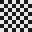

In [17]:
// Sanity check: tiny checkerboard to verify PNG + caption + saved file
use candle_notebook::candle::{Tensor, Device};
let dev = Device::Cpu;
let (h,w) = (32usize, 32usize);
let mut v = vec![0f32; h*w];
for y in 0..h { for x in 0..w {
    v[y*w + x] = if ((x/4 + y/4) % 2) == 0 { 0.1 } else { 0.9 };
}}
let g = Tensor::from_vec(v, (h, w), &dev)?;
// This emits image/png (for Plots) and an HTML caption, and saves to images_store if configured
candle_notebook::show_tensor_gray_captioned(&g, Some("Checkerboard test"), Some("32x32, 4px tiles"), None)?;

In [4]:
// No extra deps needed here. Wrapper crate `candle-notebook` re-exports image/base64/anyhow.
// Proceed to next cells.

In [18]:
use candle_notebook::candle::{Device as Dev, Tensor as T, DType as Ty};

let dev = Dev::Cpu;
let x = T::arange(0f32, 9f32, &dev)?.reshape((3,3))?;
println!("device: {:?}, dtype: {:?}, dims: {:?}", dev, Ty::F32, x.dims());
println!("x= {:?}", x.to_vec2::<f32>()?);

device: Cpu, dtype: F32, dims: [3, 3]
x= [[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]]
x= [[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]]


In [19]:
use candle_notebook::image::{RgbImage, RgbaImage, GrayImage};

// Try loading an image; fallback to a synthetic gradient if not found.
let path = std::path::Path::new("sample.png");
let img_rgb: RgbImage = if path.exists() {
    candle_notebook::image::open(path)?.to_rgb8()
} else {
    // Synthetic gradient image (256x256)
    let (w,h): (u32,u32) = (256, 256);
    let mut buf = vec![0u8; (w*h*3) as usize];
    for y in 0..h {
        for x in 0..w {
            let i = ((y*w + x)*3) as usize;
            buf[i] = x as u8;         // R
            buf[i+1] = y as u8;       // G
            buf[i+2] = ((x+y)/2) as u8; // B
        }
    }
    RgbImage::from_raw(w, h, buf).expect("rgb build")
};
let dims: (u32,u32) = img_rgb.dimensions();
println!("loaded image size: {}x{}", dims.0, dims.1);
let (w, h): (u32,u32) = dims;

loaded image size: 256x256


In [20]:
use candle_notebook::candle::{Tensor, Device};

// Convert RgbImage to Tensor (3,H,W) f32 in [0,1]
let (w, h): (u32,u32) = (w, h);
let mut f = vec![0f32; (w*h*3) as usize];
for y in 0..h { for x in 0..w {
    let i = (y*w + x) as usize;
    let p = img_rgb.get_pixel(x,y);
    f[i*3 + 0] = p[0] as f32 / 255.0;
    f[i*3 + 1] = p[1] as f32 / 255.0;
    f[i*3 + 2] = p[2] as f32 / 255.0;
}}
let img_chw = Tensor::from_vec(f, (h as usize, w as usize, 3), &Device::Cpu)?
    .permute((2,0,1))?; // (3,H,W)
println!("tensor shape: {:?}", img_chw.dims());

tensor shape: [3, 256, 256]


Caption: Original RGB  Dims: 3×256×256
Caption: Grayscale (luminance)  Dims: 256×256


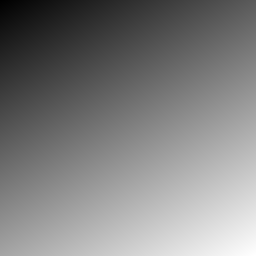

In [21]:
use candle_notebook::candle::{Tensor, Device};
use candle_notebook::candle::IndexOp;

// Show input image (RGB)
candle_notebook::show_tensor_rgb_captioned(
    &img_chw,
    Some("Original RGB"),
    Some("Loaded from file or synthetic gradient"),
    None,
)?;
// Also display as grayscale using luminance weights
let r = img_chw.i(0)?; let g = img_chw.i(1)?; let b = img_chw.i(2)?;
let gray = r.affine(0.299_f64, 0.0)?
    .add(&g.affine(0.587_f64, 0.0)?)?
    .add(&b.affine(0.114_f64, 0.0)?)?;
candle_notebook::show_tensor_gray_captioned(
    &gray,
    Some("Grayscale (luminance)"),
    Some("Weights: 0.299 R, 0.587 G, 0.114 B"),
    None,
)?;

Caption: Normalized grayscale  Dims: 256×256


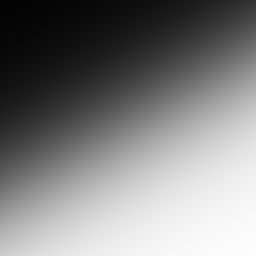

In [22]:
// Normalize grayscale: zero-mean, unit-std
let mean = gray.mean_all()?.to_scalar::<f32>()?;
let var = gray.sqr()?.mean_all()?.to_scalar::<f32>()? - mean*mean;
let std = var.max(1e-6).sqrt();
let gray_n = gray.affine(1.0f64, -(mean as f64))?.affine(1.0f64/(std as f64), 0.0)?;
// Map to [0,1] for display via sigmoid-ish squashing
let gray_disp = gray_n.tanh()?.affine(0.5, 0.5)?;
candle_notebook::show_tensor_gray_captioned(
    &gray_disp,
    Some("Normalized grayscale"),
    Some("Zero-mean, unit-std; tanh -> [0,1]"),
    None,
)?;

Caption: Blurred (3x3, 1/16 kernel)  Dims: 256×256
Caption: Sharpened (unsharp mask 3x3)  Dims: 256×256


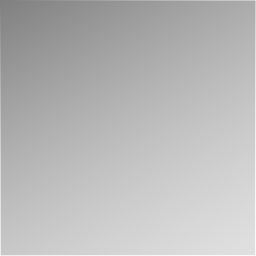

In [23]:
// Build simple 3x3 kernels
fn kernel3(vals: [f32;9]) -> candle_notebook::candle::Result<candle_notebook::candle::Tensor> {
    candle_notebook::candle::Tensor::from_slice(&vals, (3,3), &candle_notebook::candle::Device::Cpu)
}
let blur = kernel3([1.,2.,1., 2.,4.,2., 1.,2.,1.])?.affine(1.0/16.0f64, 0.0)?;
let sharpen = kernel3([0.,-1.,0., -1.,5.,-1., 0.,-1.,0.])?;
let sobel_x = kernel3([-1.,0.,1., -2.,0.,2., -1.,0.,1.])?;
let sobel_y = kernel3([-1.,-2.,-1., 0.,0.,0., 1.,2.,1.])?;

// Convolution for single-channel with padding (naive 3x3 via shifts + weighted sums).
fn conv3x3(gray: &candle_notebook::candle::Tensor, k: &candle_notebook::candle::Tensor) -> candle_notebook::candle::Result<candle_notebook::candle::Tensor> {
    use candle_notebook::candle as candle;
    let dims = gray.dims();
    if dims.len() != 2 { return Err(candle::Error::msg(format!("expected (H,W), got {:?}", dims))); }
    let (h,w) = (dims[0], dims[1]);
    let g = gray
        .pad_with_zeros(0, 1, 1)? // pad height
        .pad_with_zeros(1, 1, 1)?; // pad width
    fn at(g: &candle::Tensor, h: usize, w: usize, dy: i64, dx: i64) -> candle::Result<candle::Tensor> {
        let t = g.narrow(0, (1+dy) as usize, h)?.narrow(1, (1+dx) as usize, w)?;
        Ok(t.clone())
    }
    let wv = k.flatten_all()?.to_vec1::<f32>()?; // 9 weights
    let acc = at(&g, h, w, -1,-1)?.affine(wv[0] as f64, 0.0)?
        .add(&at(&g, h, w, -1,0)?.affine(wv[1] as f64, 0.0)?)?
        .add(&at(&g, h, w, -1,1)?.affine(wv[2] as f64, 0.0)?)?
        .add(&at(&g, h, w, 0,-1)?.affine(wv[3] as f64, 0.0)?)?
        .add(&at(&g, h, w, 0,0)?.affine(wv[4] as f64, 0.0)?)?
        .add(&at(&g, h, w, 0,1)?.affine(wv[5] as f64, 0.0)?)?
        .add(&at(&g, h, w, 1,-1)?.affine(wv[6] as f64, 0.0)?)?
        .add(&at(&g, h, w, 1,0)?.affine(wv[7] as f64, 0.0)?)?
        .add(&at(&g, h, w, 1,1)?.affine(wv[8] as f64, 0.0)?)?;
    Ok(acc)
}

let gray_blur = conv3x3(&gray, &blur)?;
let gray_sharp = conv3x3(&gray, &sharpen)?;
candle_notebook::show_tensor_gray_captioned(
    &gray_blur.tanh()?.affine(0.5,0.5)?,
    Some("Blurred (3x3, 1/16 kernel)"),
    Some("Weights [1 2 1; 2 4 2; 1 2 1]/16"),
    None,
)?;
candle_notebook::show_tensor_gray_captioned(
    &gray_sharp.tanh()?.affine(0.5,0.5)?,
    Some("Sharpened (unsharp mask 3x3)"),
    Some("Kernel [0 -1 0; -1 5 -1; 0 -1 0]"),
    None,
)?;

Caption: Sobel edge magnitude (normalized)  Dims: 256×256
Caption: Thresholded edges  Dims: 256×256


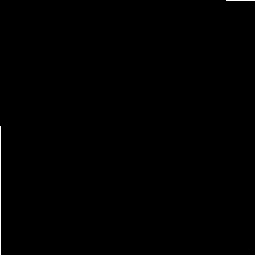

In [24]:
let gx = conv3x3(&gray, &sobel_x)?;
let gy = conv3x3(&gray, &sobel_y)?;
let mag = gx.sqr()?.add(&gy.sqr()?)?.sqrt()?;
let scale = 1.0f64 / ((mag.max_all()?.to_scalar::<f32>()? as f64) + 1e-12);
let mag_n = mag.affine(scale, 0.0)?;
candle_notebook::show_tensor_gray_captioned(
    &mag_n,
    Some("Sobel edge magnitude (normalized)"),
    Some("sqrt(gx^2 + gy^2) scaled to [0,1]"),
    None,
)?;
// Simple threshold
let thr = 0.3f32;
let mask = mag_n.ge(thr)?;
let mask_f = mask.to_dtype(candle_notebook::candle::DType::F32)?;
candle_notebook::show_tensor_gray_captioned(
    &mask_f,
    Some("Thresholded edges"),
    Some("mag > 0.3 -> 1 else 0"),
    None,
)?;

Input,Gray,Blur,Edges
,,,

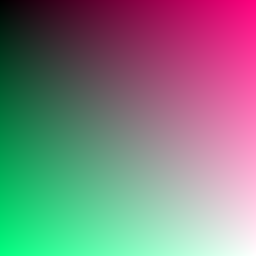
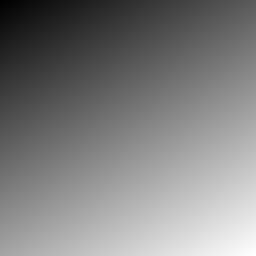
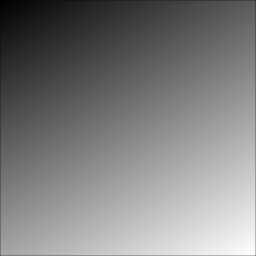
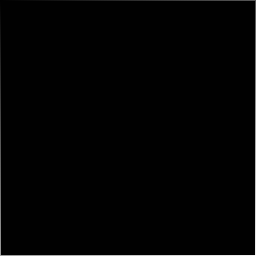

In [12]:
let html = {
    let rgb = candle_notebook::tensor_to_png_data_url_rgb(&img_chw)?;
    let gray_disp = {
        let g3 = Tensor::stack(&[&gray, &gray, &gray], 0)?;
        candle_notebook::tensor_to_png_data_url_rgb(&g3)?
    };
    let blur_disp = {
        let b = Tensor::stack(&[&gray_blur, &gray_blur, &gray_blur], 0)?;
        candle_notebook::tensor_to_png_data_url_rgb(&b)?
    };
    let edge_disp = {
        let e = Tensor::stack(&[&mag_n, &mag_n, &mag_n], 0)?;
        candle_notebook::tensor_to_png_data_url_rgb(&e)?
    };
    format!(
        "<table><tr><th>Input</th><th>Gray</th><th>Blur</th><th>Edges</th></tr>
         <tr>
           <td><img style=\"max-width:256px\" src=\"{}\"></td>
           <td><img style=\"max-width:256px\" src=\"{}\"></td>
           <td><img style=\"max-width:256px\" src=\"{}\"></td>
           <td><img style=\"max-width:256px\" src=\"{}\"></td>
         </tr></table>", rgb, gray_disp, blur_disp, edge_disp)
};
println!("EVCXR_BEGIN_CONTENT text/html\n{}\nEVCXR_END_CONTENT", html);


In [13]:
// Optional: batch process PNGs in ./imgs
let dir = std::path::Path::new("imgs");
if dir.exists() {
    let mut cells = String::new();
    cells.push_str("<table><tr>");
    for entry in std::fs::read_dir(dir)?.take(8) {
        if let Ok(e) = entry {
            let p = e.path();
            if p.extension().map(|s| s.to_string_lossy().to_lowercase()) == Some("png".into()) {
                let rgb = image::open(&p)?.to_rgb8();
                let (w,h) = rgb.dimensions();
                let mut f = vec![0f32; (w*h*3) as usize];
                for y in 0..h { for x in 0..w {
                    let i = (y*w + x) as usize; let px = rgb.get_pixel(x,y);
                    f[i*3+0] = px[0] as f32/255.0; f[i*3+1] = px[1] as f32/255.0; f[i*3+2] = px[2] as f32/255.0;
                }}
                let t = Tensor::from_vec(f, (h as usize, w as usize, 3), &Device::Cpu)?.permute((2,0,1))?;
                let url = candle_notebook::tensor_to_png_data_url_rgb(&t)?;
                cells.push_str(&format!("<td><img style=\"max-width:128px\" src=\"{}\"><br>{}</td>", url, p.file_name().unwrap().to_string_lossy()));
            }
        }
    }
    cells.push_str("</tr></table>");
    println!("EVCXR_BEGIN_CONTENT text/html\n{}\nEVCXR_END_CONTENT", cells);
} else {
    println!("No ./imgs directory found; skipping batch demo");
}


Error: failed to resolve: use of unresolved module or unlinked crate `image`

In [ ]:
// CUDA (optional): enable features in setup cell, then you can do:

// let dev = candle::Device::new_cuda(0)?; // if built with CUDA

// let img_cuda = img_chw.to_device(&dev)?; // then run ops on GPU

// For this demo, we keep CPU for widest compatibility.


## VS Code display tips

- Images are rendered inline in the output pane of each cell.

- evcxr_jupyter supports text/html and image/png via special output blocks.

- The helper functions in the `candle-notebook` crate print image/png blocks directly.

- You can right-click an output and open it in a separate tab if needed.


## Troubleshooting image display

- If no image appears, ensure your cell calls a helper that prints `EVCXR_BEGIN_CONTENT ... EVCXR_END_CONTENT` with either `text/html` or `image/png`.

- For very large images, consider downscaling or using a temporary file with an HTML `<img src="file://...">` to avoid huge base64 payloads.

- If outputs stop updating, restart the Rust kernel.


## Make images auto-open in the Plots panel

- Our helper prints `image/png` outputs, which VS Code’s Plots panel can collect.

- To auto-open Plots whenever a new image is produced:

  1. Open Settings (Ctrl+,) and search for “Plots”.

  2. Enable the options to show the Plot Viewer and to automatically show it for new plots.

  3. If you prefer workspace-level settings, use the gear icon next to each setting → “Copy Setting as JSON”, then paste it into `.vscode/settings.json` in this repo.

  4. Restart the notebook kernel after changing these settings if the Plots view does not appear automatically.



Notes:

- `jupyter.themeMatplotlibPlots` and `jupyter.widgetScriptSources` are Python-oriented (Matplotlib theming and widget loading). They’re not required for Rust/evcxr images to appear in Plots.

- If you want captions alongside images under each cell, we can update the display helper to also print a small `text/html` caption below the PNG.